# Peptides-struct (LRGB) Experiment — Results Analysis

Compares CT (original / simple / full) and GNN (GCN / GAT / GIN) on the Long Range Graph Benchmark Peptides-struct dataset.
Task: multi-task graph-level regression (11 structural targets), evaluated with mean absolute error (MAE).

In [ ]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from pathlib import Path
from IPython.display import display

plt.rcParams['figure.dpi'] = 130
pd.set_option('display.float_format', '{:.4f}'.format)

RESULTS_DIR = Path('results')

In [ ]:
FILES = {
    'CT-original': 'results_struct_ct_original.json',
    'CT-simple':   'results_struct_ct_simple.json',
    'CT-full':     'results_struct_ct_full.json',
    'GCN':         'results_struct_gcn.json',
    'GAT':         'results_struct_gat.json',
    'GIN':         'results_struct_gin.json',
    'SchNet':      'results_struct_schnet.json',
}

data = {}
for label, fname in FILES.items():
    p = RESULTS_DIR / fname
    if p.exists():
        with open(p) as f:
            data[label] = json.load(f)
    else:
        print(f'Missing: {fname}')

print(f'Loaded {len(data)} result files: {list(data.keys())}')

## Summary Table

In [ ]:
rows = []
for label, d in data.items():
    run_test_maes = [r['test_mae'] for r in d['runs']]
    run_val_maes  = [r['val_mae']  for r in d['runs']]
    rows.append({
        'model':      label,
        'num_params': d.get('num_params'),
        'val_MAE':    d['mean_val_mae'],
        'val_MAE_std': round(float(np.std(run_val_maes)), 4),
        'test_MAE':   d['mean_test_mae'],
        'test_MAE_std': round(float(np.std(run_test_maes)), 4),
    })

df = pd.DataFrame(rows).set_index('model')
df.sort_values('test_MAE', inplace=True)
display(df.style
        .format(precision=4)
        .background_gradient(subset=['val_MAE', 'test_MAE'], cmap='RdYlGn_r', axis=0))

## Test MAE Comparison — Bar Chart

In [ ]:
COLORS = {
    'CT':     '#4C72B0',
    'GCN':    '#DD8452',
    'GAT':    '#55A868',
    'GIN':    '#C44E52',
    'SchNet': '#8172B2',
}

def model_color(label):
    for prefix, c in COLORS.items():
        if label.startswith(prefix):
            return c
    return 'gray'

fig, ax = plt.subplots(figsize=(8, 5))
vals   = df['test_MAE'].dropna().sort_values()
stds   = df.loc[vals.index, 'test_MAE_std']
colors = [model_color(m) for m in vals.index]
ax.bar(range(len(vals)), vals.values, color=colors,
       yerr=stds.values, capsize=4, error_kw={'linewidth': 1.2})
ax.set_xticks(range(len(vals)))
ax.set_xticklabels(vals.index, rotation=35, ha='right', fontsize=9)
ax.set_title('Test MAE (lower is better)', fontsize=11)
ax.set_ylabel('MAE')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=k) for k, c in COLORS.items()]
ax.legend(handles=legend_elements, loc='upper left', fontsize=8)
plt.suptitle('Test MAE — mean ± std over 3 runs', fontsize=13)
plt.tight_layout()
plt.show()

## Training Loss Curves

In [ ]:
GROUPS = {
    'CT variants': [k for k in data if k.startswith('CT')],
    'GNNs':        [k for k in data if k in ('GCN', 'GAT', 'GIN')],
    'SchNet':      [k for k in data if k == 'SchNet'],
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (group_name, models) in zip(axes, GROUPS.items()):
    cmap = cm.get_cmap('tab10', max(len(models), 1))
    for idx, label in enumerate(models):
        if label not in data:
            continue
        d = data[label]
        all_losses = [r['train_losses'] for r in d['runs']]
        min_len = min(len(l) for l in all_losses)
        mean_losses = np.mean([l[:min_len] for l in all_losses], axis=0)
        color = cmap(idx)
        for l in all_losses:
            ax.plot(l[:min_len], color=color, alpha=0.25, linewidth=0.8)
        ax.plot(mean_losses, color=color, linewidth=2, label=label)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Train Loss')
    ax.set_title(group_name)
    ax.legend(fontsize=8)

plt.suptitle('Training loss (faint = individual runs, bold = mean)', fontsize=12)
plt.tight_layout()
plt.show()

## Predicted vs. True (Run 1, all 11 targets flattened)

In [ ]:
n_models = len(data)
ncols = 4
nrows = (n_models + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 4))
axes = axes.flatten()

for ax, (label, d) in zip(axes, data.items()):
    preds = d['runs'][0].get('predictions', [])
    if not preds:
        ax.set_visible(False)
        continue
    true_vals = np.array([v for p in preds for v in p['true']])
    pred_vals = np.array([v for p in preds for v in p['pred']])
    vmin, vmax = true_vals.min(), true_vals.max()
    ax.scatter(true_vals, pred_vals, alpha=0.15, s=4, rasterized=True)
    ax.plot([vmin, vmax], [vmin, vmax], 'r--', linewidth=1)
    mae = d['runs'][0]['test_mae']
    ax.set_title(f'{label}\nMAE={mae:.3f}', fontsize=9)
    ax.set_xlabel('True')
    ax.set_ylabel('Predicted')

for ax in axes[len(data):]:
    ax.set_visible(False)

plt.suptitle('Predicted vs. True values, all 11 targets pooled (run 1)', fontsize=13)
plt.tight_layout()
plt.show()

## Error Distribution (Run 1, all 11 targets flattened)

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))

for label, d in data.items():
    preds = d['runs'][0].get('predictions', [])
    if not preds:
        continue
    errors = np.array([pv - tv for p in preds for pv, tv in zip(p['pred'], p['true'])])
    ax.hist(errors, bins=60, alpha=0.5, label=f'{label} (MAE={np.abs(errors).mean():.3f})',
            density=True, histtype='stepfilled')

ax.axvline(0, color='black', linewidth=1, linestyle='--')
ax.set_xlabel('Prediction error  (pred − true)')
ax.set_ylabel('Density')
ax.set_title('Error distributions, all 11 targets pooled (run 1)')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Runtime & Parameter Count

In [ ]:
rt_rows = []
for label, d in data.items():
    runtimes = [r.get('runtime') for r in d['runs'] if r.get('runtime')]
    rt_rows.append({
        'model':          label,
        'num_params':     d.get('num_params'),
        'total_runtime_h': round(sum(runtimes) / 3600, 2) if runtimes else None,
        'per_run_h':       round(np.mean(runtimes) / 3600, 2) if runtimes else None,
    })

rt_df = pd.DataFrame(rt_rows).set_index('model').sort_values('per_run_h')
display(rt_df)

## MAE Table (for slides)

In [ ]:
mae_df = df[['test_MAE', 'test_MAE_std']].sort_values('test_MAE').reset_index()

fig, ax = plt.subplots(figsize=(4.5, 0.5 + 0.45 * len(mae_df)))
ax.axis('off')

table = ax.table(
    cellText=[[m, f'{mae:.4f} ± {std:.4f}'] for m, mae, std in mae_df.values],
    colLabels=['Model', 'MAE'],
    cellLoc='center',
    loc='center',
)
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1, 1.8)

for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor('black')
    if row == 0:
        cell.set_text_props(weight='bold')

plt.tight_layout()
plt.savefig('mae_table.jpg', dpi=300, bbox_inches='tight')
plt.show()

## Model Feature Overview (for slides)

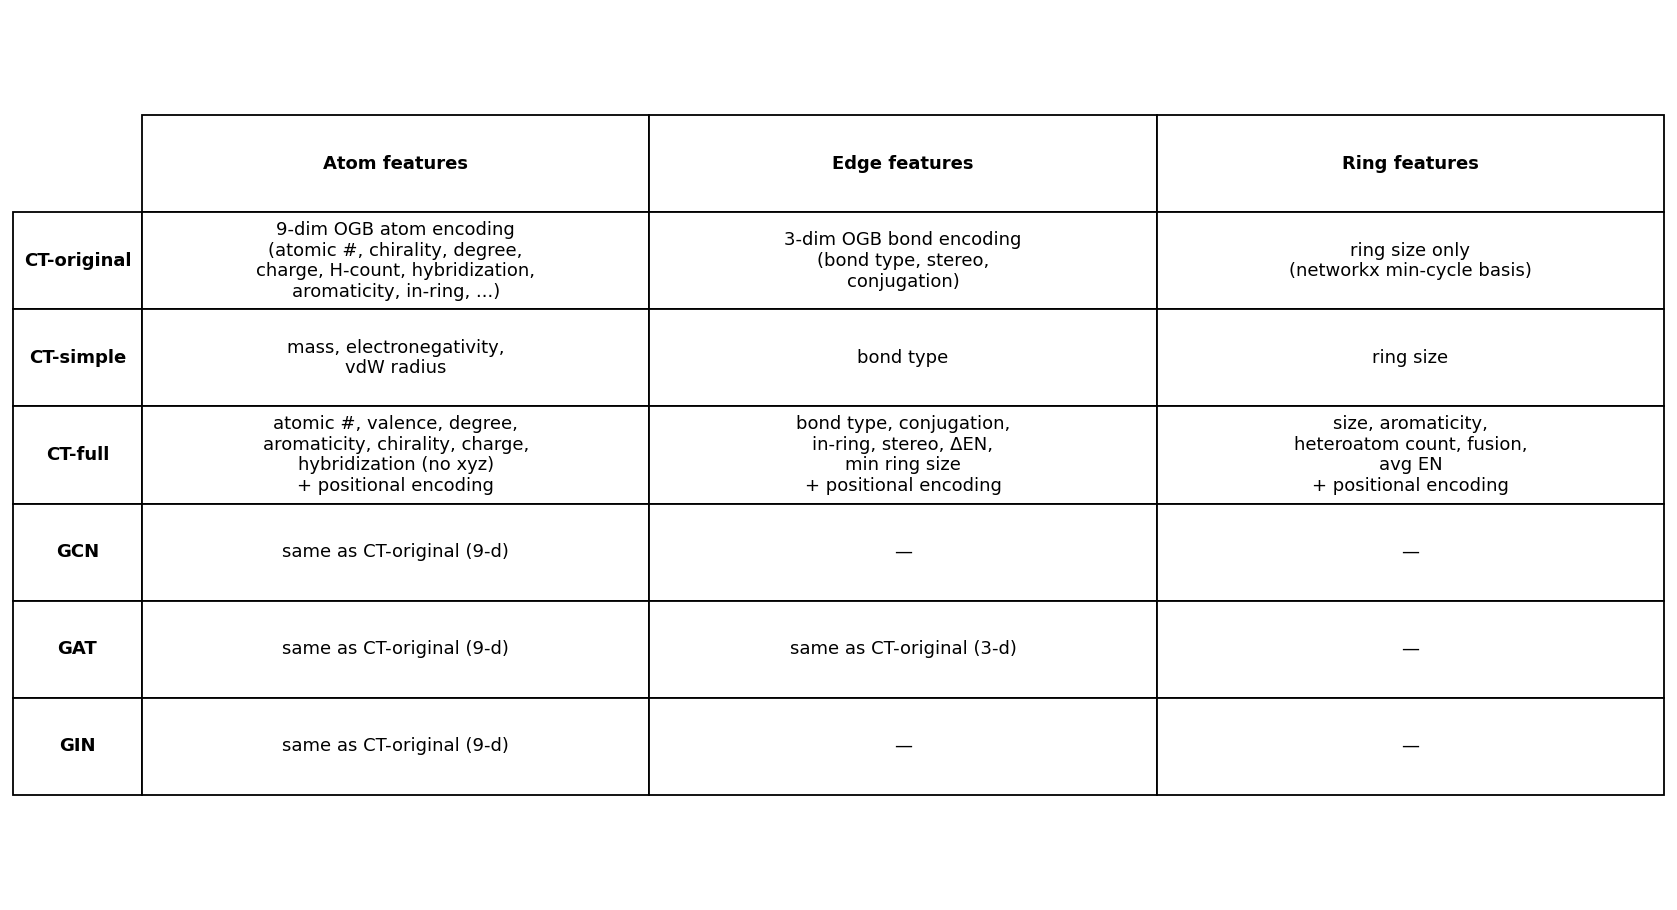

In [11]:
FEATURE_OVERVIEW = [
    ('CT-original', '9-dim OGB atom encoding\n(atomic #, chirality, degree,\ncharge, H-count, hybridization,\naromaticity, in-ring, ...)',
                     '3-dim OGB bond encoding\n(bond type, stereo,\nconjugation)',
                     'ring size only\n(networkx min-cycle basis)'),
    ('CT-simple',   'mass, electronegativity,\nvdW radius',
                     'bond type',
                     'ring size'),
    ('CT-full',     'atomic #, valence, degree,\naromaticity, chirality, charge,\nhybridization (no xyz)\n+ positional encoding',
                     'bond type, conjugation,\nin-ring, stereo, ΔEN,\nmin ring size\n+ positional encoding',
                     'size, aromaticity,\nheteroatom count, fusion,\navg EN\n+ positional encoding'),
    ('GCN',         'same as CT-original (9-d)', '—', '—'),
    ('GAT',         'same as CT-original (9-d)', 'same as CT-original (3-d)', '—'),
    ('GIN',         'same as CT-original (9-d)', '—', '—'),
    #('SchNet',      'atomic number only\n(+ RDKit-embedded 3D\nconformer coordinates)', '— (implicit, via learned\ndistance cutoff)', '—'),
]

fig, ax = plt.subplots(figsize=(13, 0.5 + 1.1 * len(FEATURE_OVERVIEW)))
ax.axis('off')

table = ax.table(
    cellText=[list(row[1:]) for row in FEATURE_OVERVIEW],
    rowLabels=[row[0] for row in FEATURE_OVERVIEW],
    colLabels=['Atom features', 'Edge features', 'Ring features'],
    cellLoc='center',
    loc='center',
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 3.6)

for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor('black')
    cell.set_text_props(ha='center', va='center')
    if row == 0 or col == -1:
        cell.set_text_props(weight='bold', ha='center', va='center')

plt.tight_layout()
plt.savefig('feature_table.jpg', dpi=300, bbox_inches='tight')
plt.show()